In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
data_path = ("/kaggle/input/notebooks/phyothaw/06-target-and-model-dataset-ipynb/model_ready_complete_case_2020_2025.csv")
data_df = pd.read_csv(data_path)
data_df["date"] = pd.to_datetime(data_df["date"])

print("Dataset shape:", data_df.shape)

print("\nDate Range")
print("Start:", data_df["date"].min())
print("End  :", data_df["date"].max())

Dataset shape: (7370, 42)

Date Range
Start: 2020-01-13 00:00:00
End  : 2025-12-22 00:00:00


In [3]:
data_df["gdelt_tone_missing"] = (data_df["gdelt_company_tone"].isna().astype(int))
data_df["gdelt_company_tone"] = (data_df["gdelt_company_tone"].fillna(0))

print("Remaining missing values:")
missing_values = (data_df.isna().sum().sort_values(ascending=False))
display(missing_values[missing_values > 0].to_frame("Missing Count"))

Remaining missing values:


,Missing Count


In [4]:
TARGET = "target_5d"

DROP_COLUMNS = [
    "ticker",
    "date",
    "future_close_5d",
    "forward_return_5d",
    "movement_5d",
    "target_5d",
    "Dividends",
    "Stock Splits"
]

FEATURE_COLUMNS = [column for column in data_df.columns if column not in DROP_COLUMNS]

print("Number of features:", len(FEATURE_COLUMNS))
print("\nFeatures:")
print(FEATURE_COLUMNS)

Number of features: 34

Features:
['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_50', 'SMA_200', 'EMA_50', 'EMA_200', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'ATR', 'ADX', 'gdelt_company_tone', 'gdelt_tone_missing', 'gdelt_tone_lag_1', 'gdelt_tone_mean_3', 'gdelt_tone_mean_5', 'gdelt_tone_std_5', 'gdelt_tone_change_1d', 'gdelt_abnormal_tone_20', 'market_close', 'market_return', 'vix_close', 'vix_change', 'market_return_lag_1', 'vix_close_lag_1', 'vix_change_lag_1', 'daily_return_check']


### Feature Selection

The following columns are excluded from the model features:

- **`ticker` and `date`** — identifiers and metadata rather than predictive input features.
- **`future_close_5d` and `forward_return_5d`** — future information used to construct the prediction target, so including them would cause data leakage.
- **`movement_5d` and `target_5d`** — target variables that the models are trained to predict and therefore must not be included as input features.
- **`Dividends` and `Stock Splits`** — excluded to keep the feature set focused on the market, technical, news, and broader market-context variables used in the modelling design.

The remaining columns are used as input features for the explainability analysis, using the same feature definition as the baseline modelling stage.

In [5]:
stocks = sorted(data_df["ticker"].unique())

print("Stocks:")
print(stocks)

Stocks:
['BRK-B', 'CVX', 'GE', 'MSFT', 'NVDA']


In [6]:
RANDOM_STATE = 42
TEST_YEAR = 2025

In [7]:
stock_data = {}

for stock in stocks:

    stock_df = data_df[data_df["ticker"] == stock].copy()
    train_df = stock_df[stock_df["date"].dt.year < TEST_YEAR].copy()
    test_df = stock_df[stock_df["date"].dt.year == TEST_YEAR].copy()

    x_train = train_df[FEATURE_COLUMNS]
    y_train = train_df[TARGET]

    x_test = test_df[FEATURE_COLUMNS]
    y_test = test_df[TARGET]

    stock_data[stock] = {
        "x_train": x_train,
        "y_train": y_train,
        "x_test": x_test,
        "y_test": y_test,
        "test_dates": test_df["date"].reset_index(drop=True)
    }

    print(f"{stock}")
    print(f"Training samples : {len(train_df)}")
    print(f"Testing samples  : {len(test_df)}")
    print("-" * 40)

BRK-B
Training samples : 1248
Testing samples  : 226
----------------------------------------
CVX
Training samples : 1248
Testing samples  : 226
----------------------------------------
GE
Training samples : 1248
Testing samples  : 226
----------------------------------------
MSFT
Training samples : 1248
Testing samples  : 226
----------------------------------------
NVDA
Training samples : 1248
Testing samples  : 226
----------------------------------------


In [8]:
rf_models = {}
xgb_models = {}

for stock in stocks:

    x_train = stock_data[stock]["x_train"]
    y_train = stock_data[stock]["y_train"]

    # Random Forest
    rf_model = RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced")
    rf_model.fit(x_train, y_train)
    rf_models[stock] = rf_model

    # XGBoost
    xgb_model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE
    )

    xgb_model.fit(x_train, y_train)
    xgb_models[stock] = xgb_model
    print(f"{stock}: RF and XGBoost trained")

BRK-B: RF and XGBoost trained
CVX: RF and XGBoost trained
GE: RF and XGBoost trained
MSFT: RF and XGBoost trained
NVDA: RF and XGBoost trained


In [9]:
for stock in stocks:

    x_test = stock_data[stock]["x_test"]

    rf_pred = rf_models[stock].predict(x_test)
    xgb_pred = xgb_models[stock].predict(x_test)

    print(f"{stock}")
    print("RF predictions :", len(rf_pred))
    print("XGB predictions:", len(xgb_pred))
    print("-" * 40)

BRK-B
RF predictions : 226
XGB predictions: 226
----------------------------------------
CVX
RF predictions : 226
XGB predictions: 226
----------------------------------------
GE
RF predictions : 226
XGB predictions: 226
----------------------------------------
MSFT
RF predictions : 226
XGB predictions: 226
----------------------------------------
NVDA
RF predictions : 226
XGB predictions: 226
----------------------------------------


In [10]:
rf_explainers = {}
xgb_explainers = {}

for stock in stocks:
    rf_explainers[stock] = shap.TreeExplainer(rf_models[stock])
    xgb_explainers[stock] = shap.TreeExplainer(xgb_models[stock])

In [11]:
rf_shap_values = {}
xgb_shap_values = {}

for stock in stocks:
    x_test = stock_data[stock]["x_test"]

    rf_shap_values[stock] = (rf_explainers[stock].shap_values(x_test))
    xgb_shap_values[stock] = (xgb_explainers[stock].shap_values(x_test))

    print(f"{stock}: SHAP values calculated")

BRK-B: SHAP values calculated
CVX: SHAP values calculated
GE: SHAP values calculated
MSFT: SHAP values calculated
NVDA: SHAP values calculated


In [12]:
stock = stocks[0]

print("Stock:", stock)

print("RF SHAP type:")
print(type(rf_shap_values[stock]))

print("\nRF SHAP shape:")
print(np.array(rf_shap_values[stock]).shape)

print("\nXGBoost SHAP type:")
print(type(xgb_shap_values[stock]))

print("\nXGBoost SHAP shape:")
print(np.array(xgb_shap_values[stock]).shape)

Stock: BRK-B
RF SHAP type:
<class 'numpy.ndarray'>

RF SHAP shape:
(226, 34, 3)

XGBoost SHAP type:
<class 'numpy.ndarray'>

XGBoost SHAP shape:
(226, 34, 3)


In [13]:
CLASS_NAMES = {
    0: "Down",
    1: "Neutral",
    2: "Up"
}

print(CLASS_NAMES)

{0: 'Down', 1: 'Neutral', 2: 'Up'}


**Random Forest**

In [14]:
rf_overall_importance = {}

for stock in stocks:
    values = rf_shap_values[stock]

    importance = np.mean(np.abs(values), axis=(0, 2))
    rf_overall_importance[stock] = pd.Series(importance,index=FEATURE_COLUMNS).sort_values(ascending=False)

**XGBoost**

In [15]:
xgb_overall_importance = {}

for stock in stocks:
    values = xgb_shap_values[stock]
    importance = np.mean(np.abs(values),axis=(0, 2))
    xgb_overall_importance[stock] = pd.Series(importance,index=FEATURE_COLUMNS).sort_values(ascending=False)

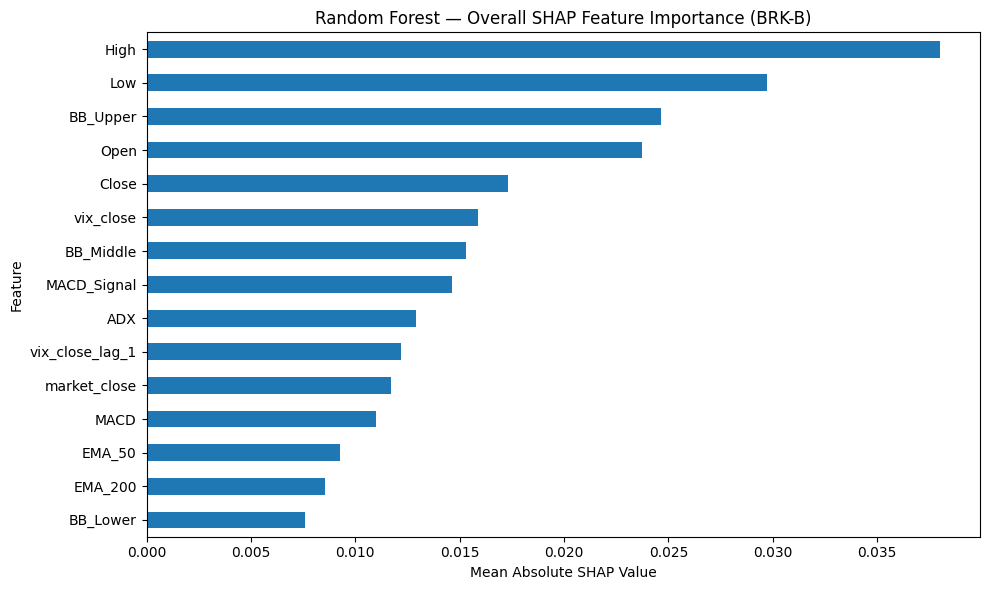

In [16]:
stock = "BRK-B"

rf_importance = (rf_overall_importance[stock].head(15).sort_values())

plt.figure(figsize=(10, 6))
rf_importance.plot(kind="barh")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title(f"Random Forest — Overall SHAP Feature Importance ({stock})")

plt.tight_layout()
plt.show()

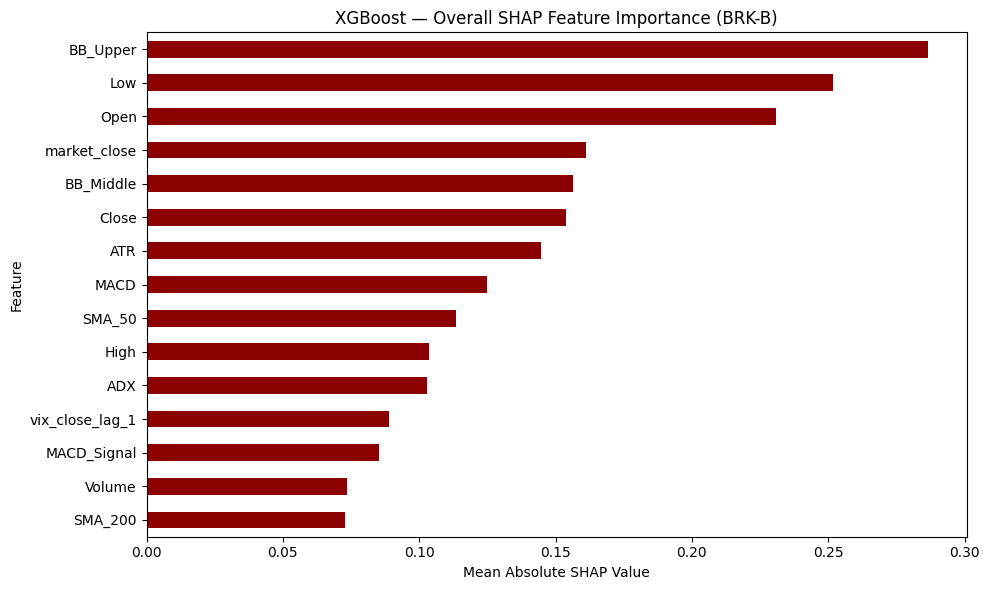

In [17]:
xgb_importance = (
    xgb_overall_importance[stock]
    .head(15)
    .sort_values()
)

plt.figure(figsize=(10, 6))

xgb_importance.plot(kind="barh", color=["darkred"])

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title(
    f"XGBoost — Overall SHAP Feature Importance ({stock})"
)

plt.tight_layout()
plt.show()

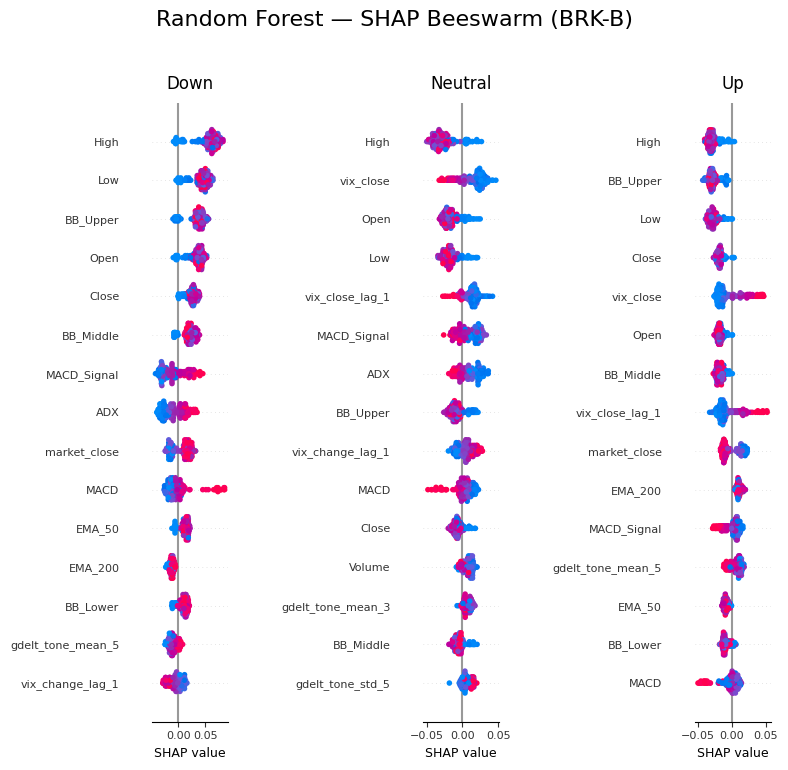

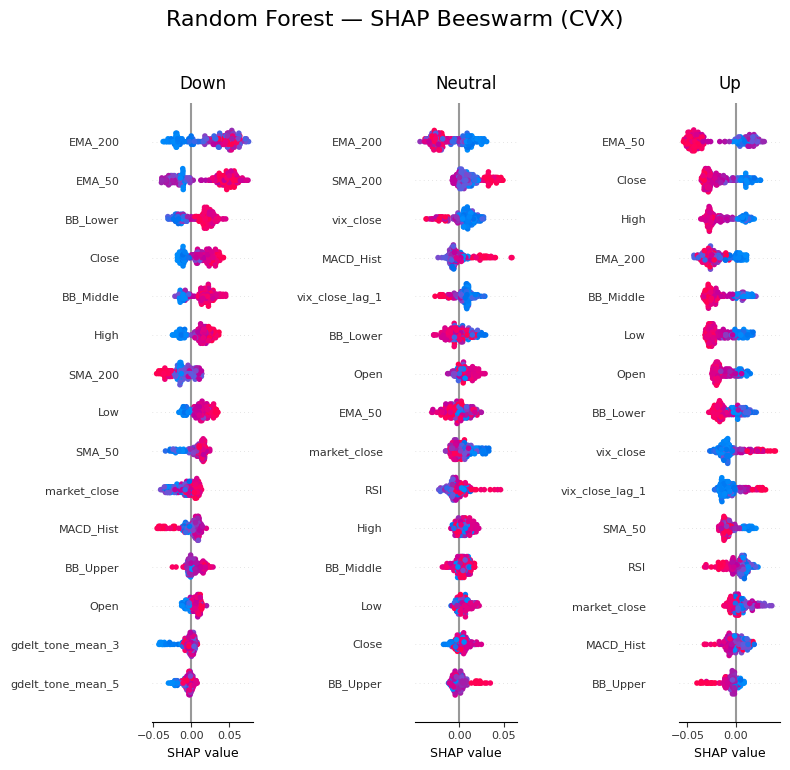

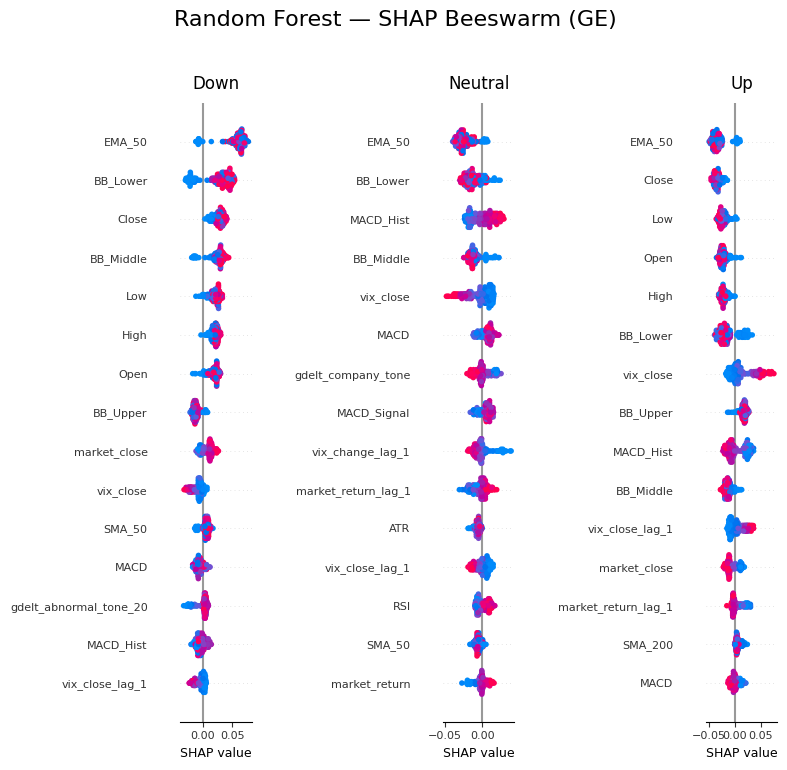

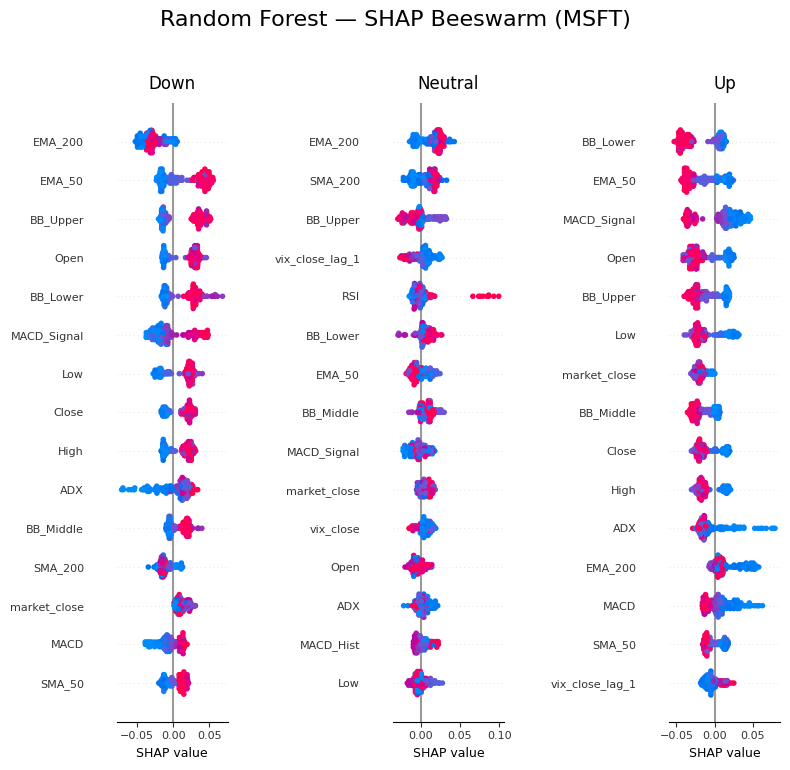

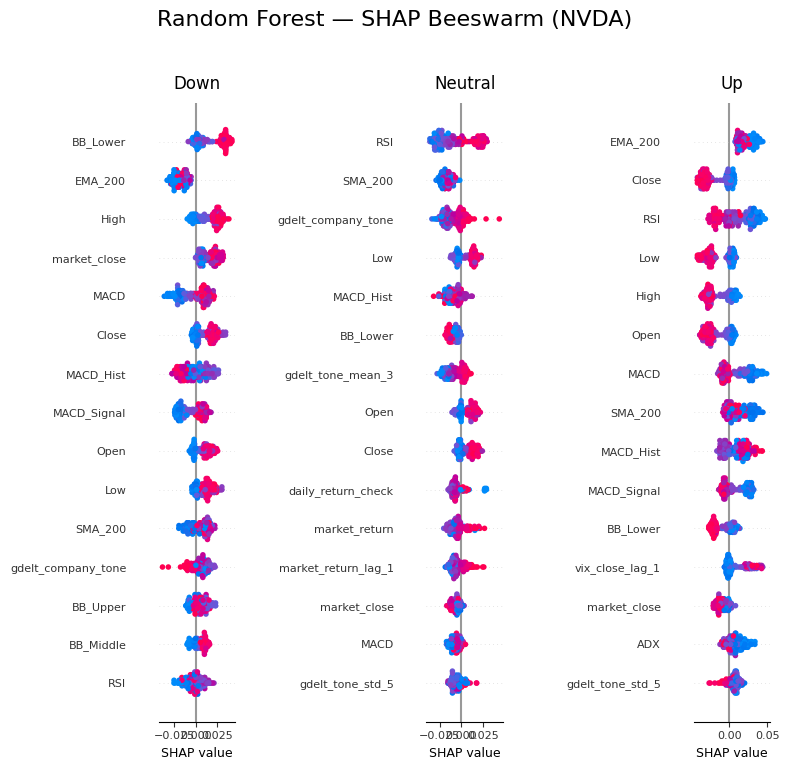

In [18]:
for stock in stocks:

    # 1. Widen the figure significantly (from 10 to 22+) so 3 plots can fit side-by-side
    fig, axes = plt.subplots(1, 3, figsize=(22, 7))

    for class_index, class_name in CLASS_NAMES.items():
        rf_values = rf_shap_values[stock][:, :, class_index]
        plt.sca(axes[class_index])
        
        shap.summary_plot(
            rf_values,
            stock_data[stock]["x_test"],
            feature_names=FEATURE_COLUMNS,
            max_display=15,
            color_bar=False,  # 2. Turn this off! Multiple colorbars will crash into the adjacent plots
            show=False
        )
        
        # 3. Shrink the y-axis (feature names) font size here
        axes[class_index].tick_params(axis='y', labelsize=8) 
        
        # 4. Optional: Shrink x-axis ticks to match the clean look
        axes[class_index].tick_params(axis='x', labelsize=8)
        
        # 5. Clean up labels so they don't look crowded
        axes[class_index].set_title(f"{class_name}", fontsize=12, pad=10)
        axes[class_index].set_xlabel("SHAP value", fontsize=9)

    fig.suptitle(f"Random Forest — SHAP Beeswarm ({stock})", fontsize=16, y=1.02)
    
    # 6. Use w_pad to give breathing room between the 3 columns
    plt.tight_layout(w_pad=3)
    plt.show()


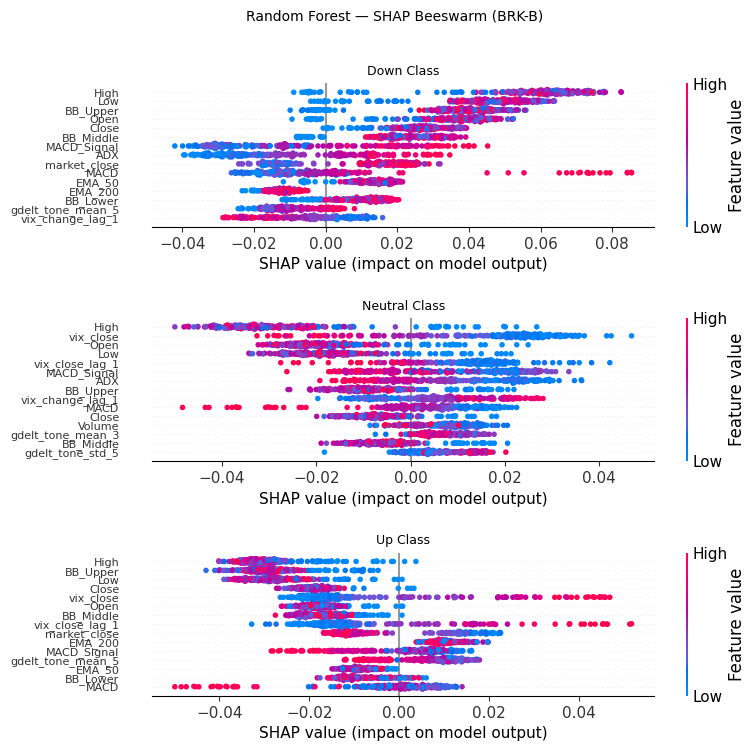

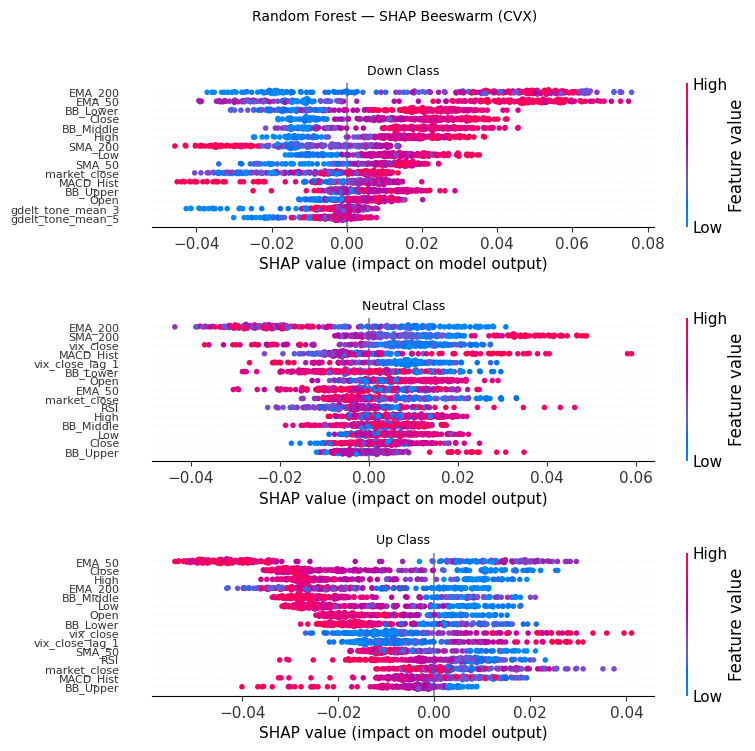

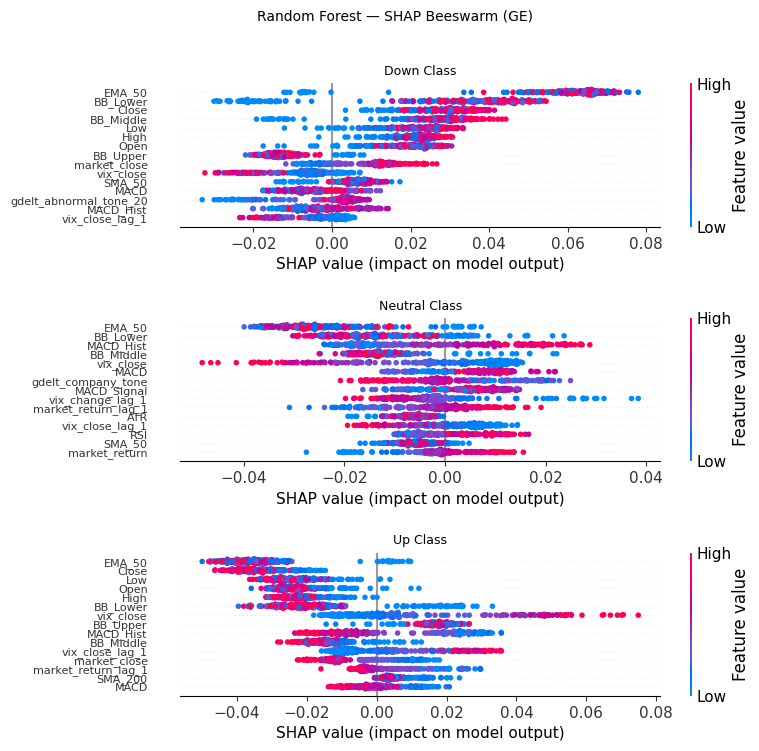

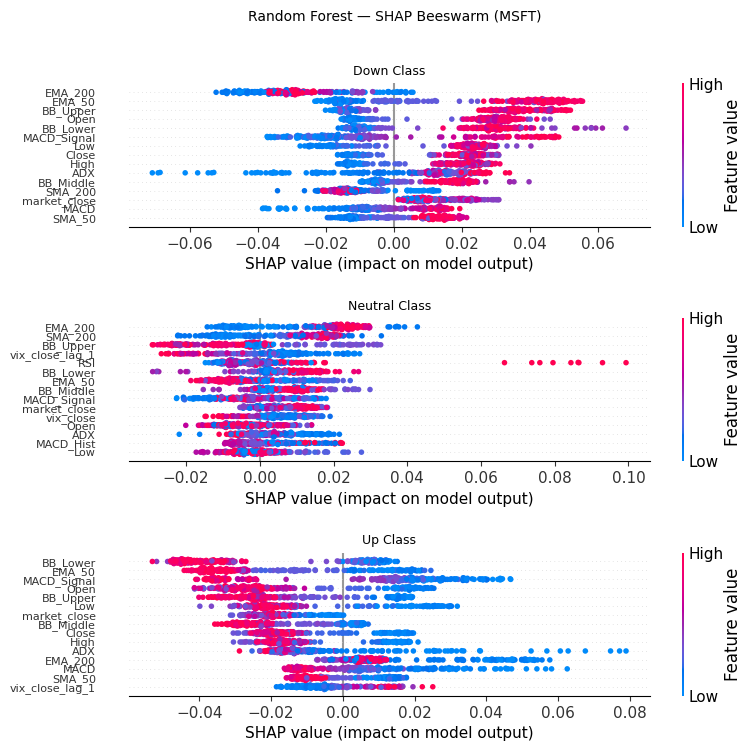

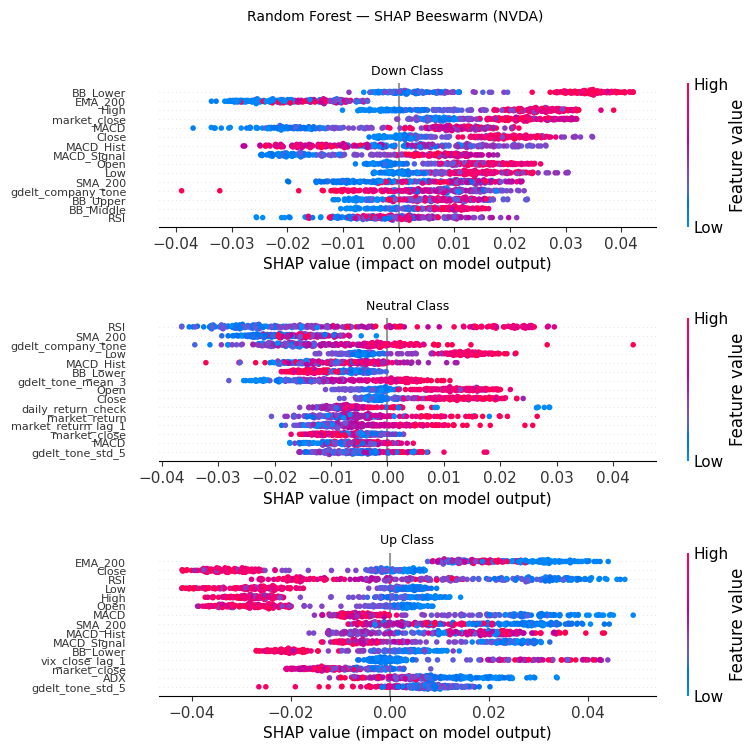

In [19]:
for stock in stocks:

    fig, axes = plt.subplots(3, 1, figsize=(12, 10))

    for class_index, class_name in CLASS_NAMES.items():

        rf_values = rf_shap_values[stock][:, :, class_index]

        plt.sca(axes[class_index])

        shap.summary_plot(
            rf_values,
            stock_data[stock]["x_test"],
            feature_names=FEATURE_COLUMNS,
            max_display=15,
            color_bar=True,
            show=False
        )

        axes[class_index].tick_params(axis='y', labelsize=8)  # Adjust 8 to your preferred size

        axes[class_index].set_title(
            f"{class_name} Class",
            fontsize=9
        )

        axes[class_index].set_xlabel(
            "SHAP value (impact on model output)",
            fontsize=11
        )

    fig.suptitle(
        f"Random Forest — SHAP Beeswarm ({stock})",
        fontsize=10,
        y=0.995
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.98],
        h_pad=2
    )

    plt.show()

In [20]:
rf_all_shap = np.concatenate([rf_shap_values[stock]for stock in stocks],axis=0)
print("RF SHAP shape:", rf_all_shap.shape)

xgb_all_shap = np.concatenate([xgb_shap_values[stock] for stock in stocks], axis=0)
print("XGBoost SHAP shape:", xgb_all_shap.shape)

RF SHAP shape: (1130, 34, 3)
XGBoost SHAP shape: (1130, 34, 3)


In [21]:
rf_overall_importance = np.mean(np.abs(rf_all_shap),axis=(0, 2))
rf_overall_df = (pd.DataFrame({"feature": FEATURE_COLUMNS, "mean_abs_shap": rf_overall_importance }).sort_values( "mean_abs_shap", ascending=False))

display(rf_overall_df.head(15))

,feature,mean_abs_shap
7,EMA_50,0.019379
1,High,0.018896
2,Low,0.017518
3,Close,0.016549
0,Open,0.015958
15,BB_Lower,0.015584
8,EMA_200,0.014830
13,BB_Upper,0.013753
14,BB_Middle,0.013532
11,MACD_Signal,0.010677


In [22]:
xgb_overall_importance = np.mean(
    np.abs(xgb_all_shap),
    axis=(0, 2)
)

xgb_overall_df = (
    pd.DataFrame({
        "feature": FEATURE_COLUMNS,
        "mean_abs_shap": xgb_overall_importance
    })
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
)

display(xgb_overall_df.head(15))

,feature,mean_abs_shap
6,SMA_200,0.151627
2,Low,0.149906
26,market_close,0.144687
3,Close,0.142189
15,BB_Lower,0.134104
8,EMA_200,0.131147
1,High,0.121335
12,MACD_Hist,0.115377
13,BB_Upper,0.105414
7,EMA_50,0.098119


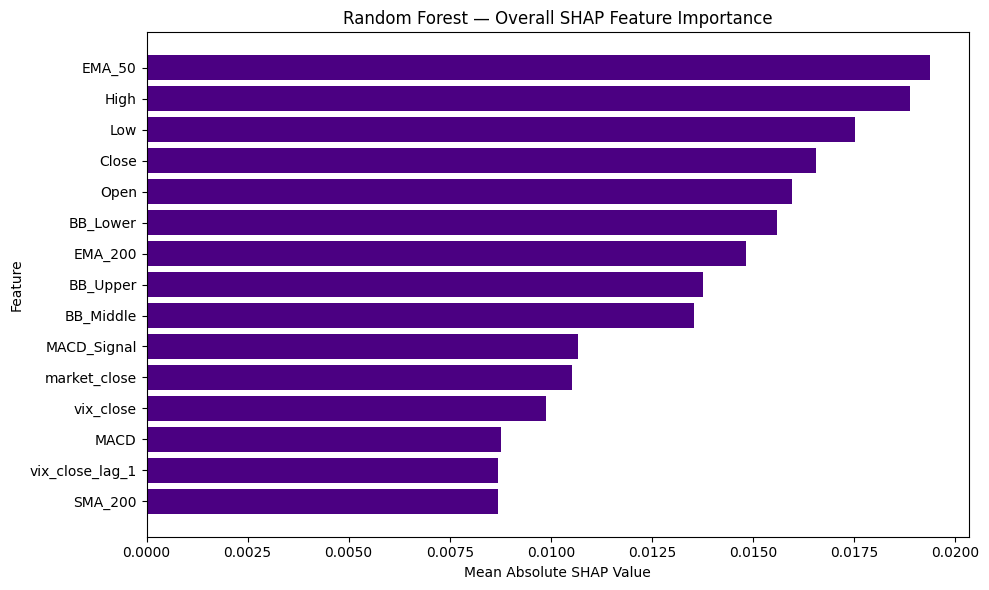

In [23]:
rf_plot_df = (
    rf_overall_df
    .head(15)
    .sort_values("mean_abs_shap")
)

plt.figure(figsize=(10, 6))

plt.barh(
    rf_plot_df["feature"],
    rf_plot_df["mean_abs_shap"],
    color = ["indigo"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title(
    "Random Forest — Overall SHAP Feature Importance"
)

plt.tight_layout()
plt.show()

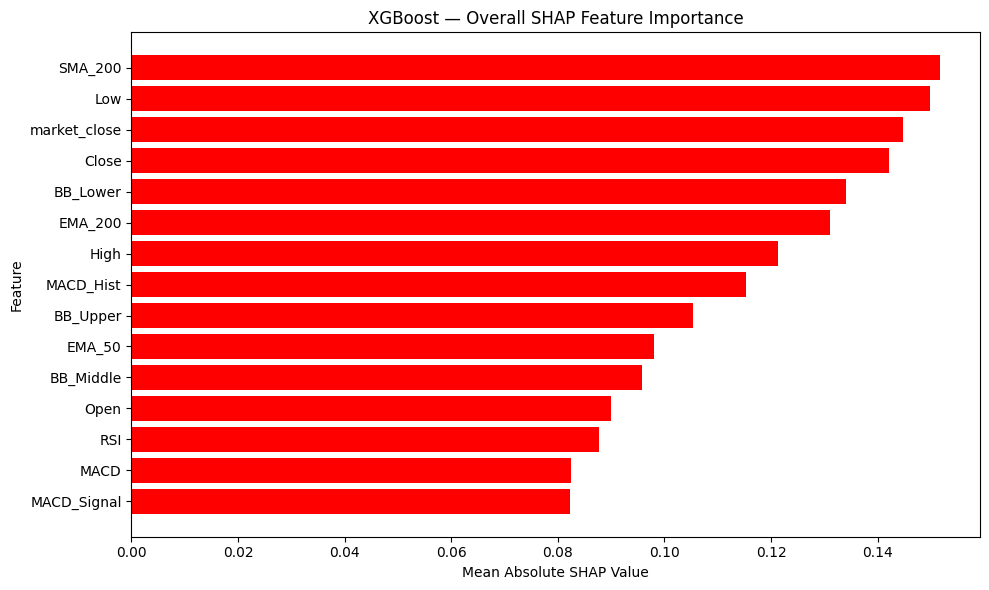

In [24]:
xgb_plot_df = (
    xgb_overall_df
    .head(15)
    .sort_values("mean_abs_shap")
)

plt.figure(figsize=(10, 6))

plt.barh(
    xgb_plot_df["feature"],
    xgb_plot_df["mean_abs_shap"],
    color = ["red"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title(
    "XGBoost — Overall SHAP Feature Importance"
)

plt.tight_layout()
plt.show()

In [25]:
rf_rank = rf_overall_df.copy()
rf_rank["RF_Rank"] = range(1, len(rf_rank) + 1)

xgb_rank = xgb_overall_df.copy()
xgb_rank["XGB_Rank"] = range(1, len(xgb_rank) + 1)

comparison_df = (
    rf_rank[["feature", "RF_Rank", "mean_abs_shap"]]
    .rename(columns={"mean_abs_shap": "RF_Mean_Abs_SHAP"})
    .merge(xgb_rank[["feature", "XGB_Rank", "mean_abs_shap"]].rename(columns={"mean_abs_shap": "XGB_Mean_Abs_SHAP"}), on="feature").sort_values("RF_Rank"))

display(comparison_df.head(15))

,feature,RF_Rank,RF_Mean_Abs_SHAP,XGB_Rank,XGB_Mean_Abs_SHAP
0,EMA_50,1,0.019379,10,0.098119
1,High,2,0.018896,7,0.121335
2,Low,3,0.017518,2,0.149906
3,Close,4,0.016549,4,0.142189
4,Open,5,0.015958,12,0.089942
5,BB_Lower,6,0.015584,5,0.134104
6,EMA_200,7,0.014830,6,0.131147
7,BB_Upper,8,0.013753,9,0.105414
8,BB_Middle,9,0.013532,11,0.095803
9,MACD_Signal,10,0.010677,15,0.082360


In [26]:
rf_overall_df.to_csv("/kaggle/working/rf_overall_shap_importance.csv",index=False)
xgb_overall_df.to_csv("/kaggle/working/xgb_overall_shap_importance.csv",index=False)
comparison_df.to_csv("/kaggle/working/rf_xgb_shap_comparison.csv",index=False)

print("SHAP importance files saved.")

SHAP importance files saved.
